#CO2 Emissions Prediction Using Regression Models

##Introduction
This project aims to analyze vehicle characteristics and predict CO2 emissions using regression models using a Canadian vehicles dataset.


## Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

##Loading the Dataset


In [ ]:
path = kagglehub.dataset_download("debajyotipodder/co2-emission-by-vehicles")
df = pd.read_csv(f"{path}/CO2 Emissions_Canada.csv")



Using Colab cache for faster access to the 'co2-emission-by-vehicles' dataset.


## Data Cleaning
### Removing Duplicates


In [ ]:

print(f"Original Shape: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")


Original Shape: (7385, 12)
Shape after removing duplicates: (6282, 12)


## Exploratory Data Analysis (EDA)
### Distribution of CO2 Emissions


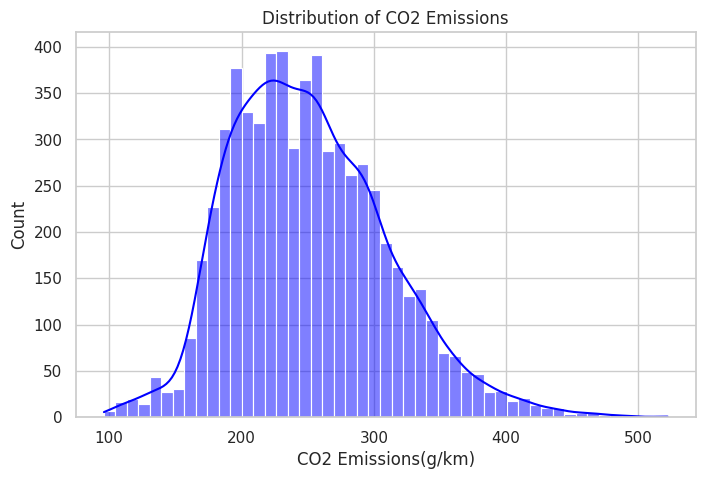

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['CO2 Emissions(g/km)'], kde=True, color='blue')
plt.title('Distribution of CO2 Emissions')
plt.show()

## Data Preprocessing
### Encoding Categorical Features


In [ ]:
categorical_cols = ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print(" Categorical columns encoded.")



 Categorical columns encoded.


### Outlier Detection and Removal


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
df = df_clean.copy()
print(f"Shape after outlier removal: {df.shape}")

Shape after outlier removal: (5446, 12)


## Exploratory Data Analysis (EDA) – Continued
### Correlation and Feature Relationships


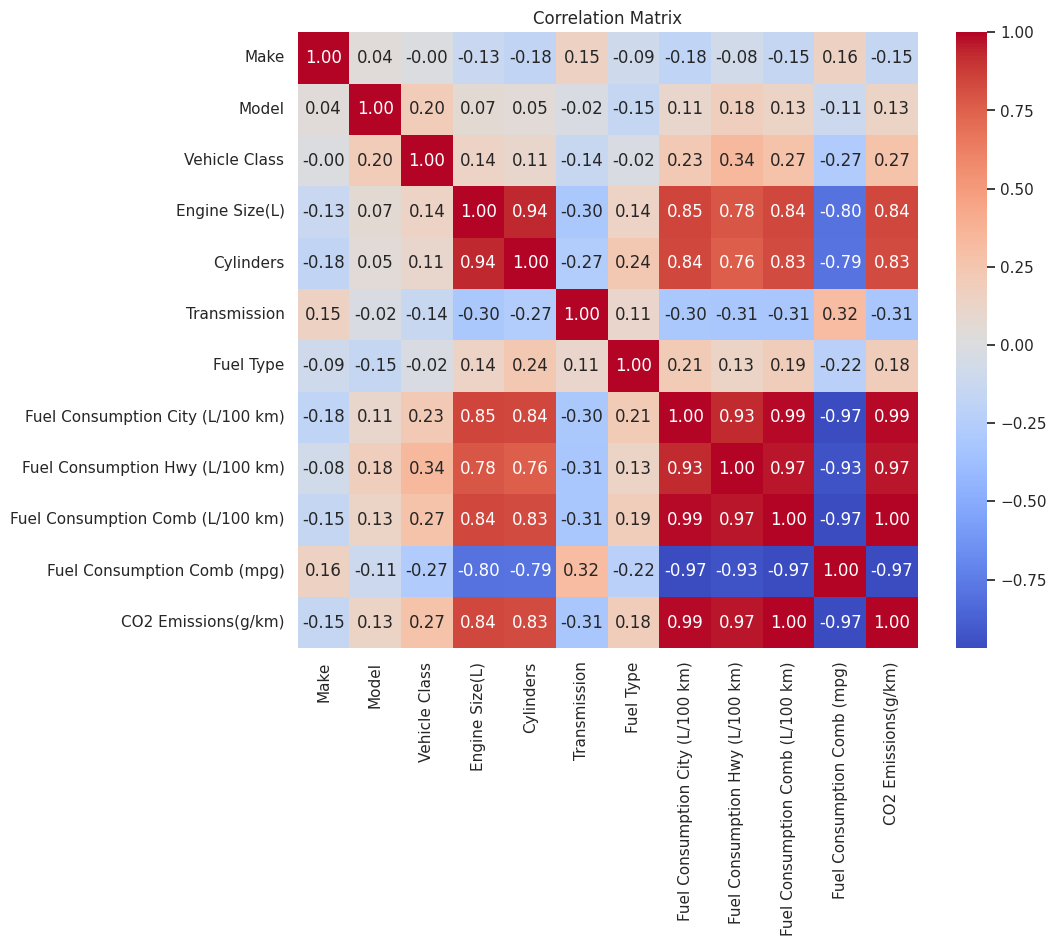

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix reveals a strong positive correlation between Engine Size and CO2 Emissions, whereas a negative correlation is observed with Fuel Consumption (mpg).

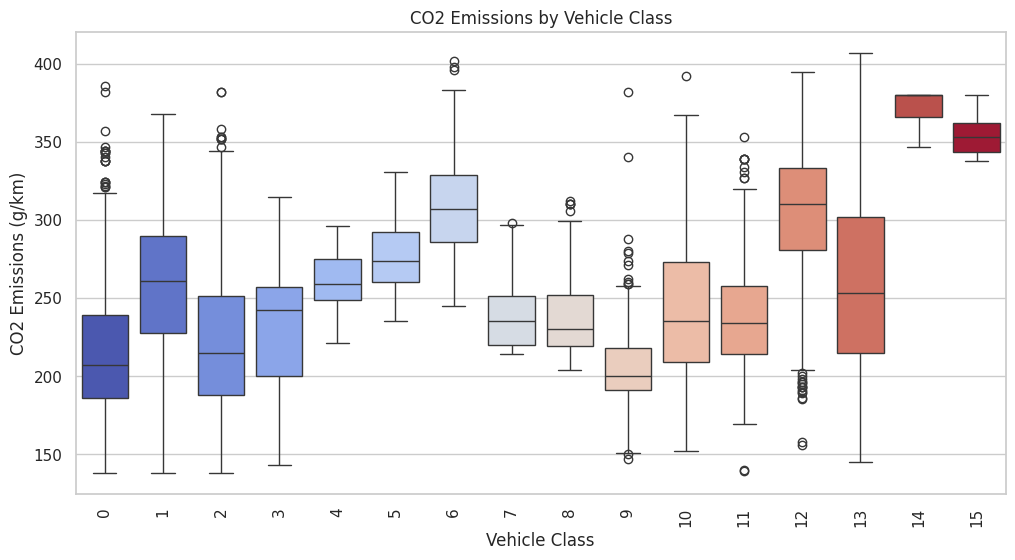

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Vehicle Class', y='CO2 Emissions(g/km)', data=df, hue='Vehicle Class', palette='coolwarm', legend=False)
plt.title('CO2 Emissions by Vehicle Class')
plt.xticks(rotation=90)
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

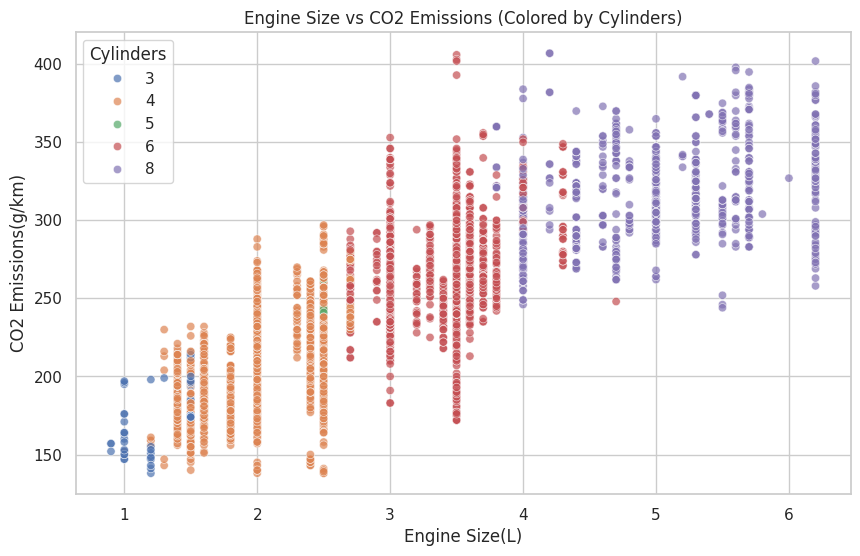

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', hue='Cylinders', data=df, palette='deep', alpha=0.7)
plt.title('Engine Size vs CO2 Emissions (Colored by Cylinders)')
plt.show()

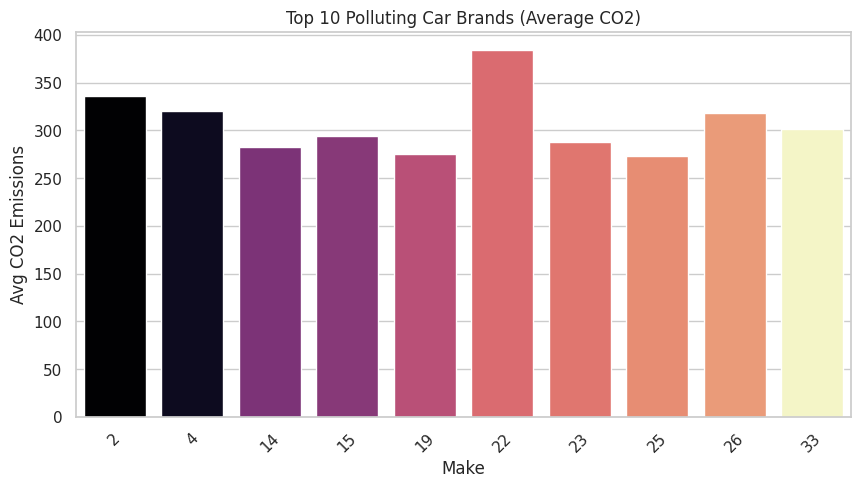

In [ ]:
top_10_makes = df.groupby('Make')['CO2 Emissions(g/km)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_makes.index, y=top_10_makes.values, hue=top_10_makes.index, palette='magma', legend=False)
plt.title('Top 10 Polluting Car Brands (Average CO2)')
plt.xticks(rotation=45)
plt.ylabel('Avg CO2 Emissions')
plt.show()

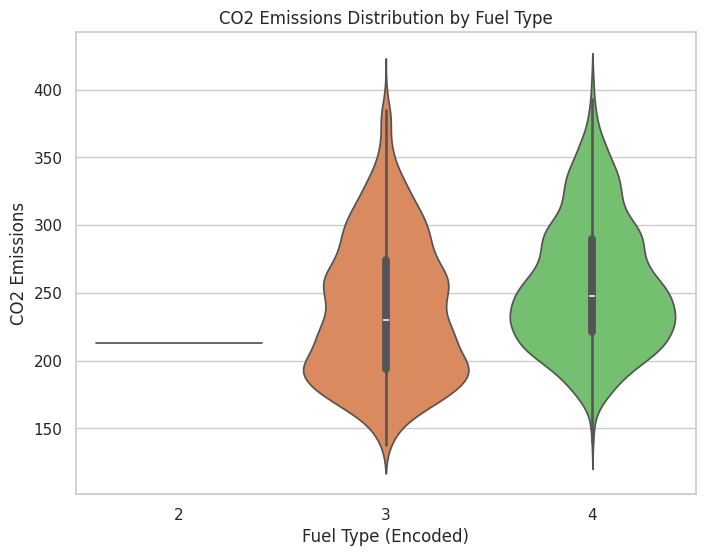

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Fuel Type', y='CO2 Emissions(g/km)', data=df, hue='Fuel Type', palette='muted', legend=False)
plt.title('CO2 Emissions Distribution by Fuel Type')
plt.xlabel('Fuel Type (Encoded)')
plt.ylabel('CO2 Emissions')
plt.show()

## Feature Selection


In [ ]:
cols_to_drop = [
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Fuel Consumption Comb (mpg)'
]
X = df.drop(cols_to_drop + ["CO2 Emissions(g/km)"], axis=1)
y = df["CO2 Emissions(g/km)"]

## Train–Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Feature Scaling


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

results = []
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"🔹 {name}")
    print(f"  R2 Score : {r2:.4f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE : {mae:.2f}")

    results.append({
        'Model': name,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MSE': mse
    })
    return r2

## Model Training
### Linear Regression


In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, y_pred_lr)

🔹 Linear Regression
  R2 Score : 0.7538
  RMSE : 25.41
  MAE : 19.41


0.753766628503733

### Polynomial Regression


In [ ]:
train_rmse_errors = []
test_rmse_errors = []
degrees = range(1, 8)

best_degree = 1
min_test_rmse = float('inf')
overfitting_threshold = 2.0

for d in degrees:

    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)


    model = LinearRegression()
    model.fit(X_train_poly, y_train)


    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))


    diff = test_rmse - train_rmse

    print(f"Degree {d}: Test RMSE={test_rmse:.2f}, Diff={diff:.2f}")

    if test_rmse < min_test_rmse and diff < overfitting_threshold:
        min_test_rmse = test_rmse
        best_degree = d

print(f"\n Best Stable Degree is {best_degree} (RMSE: {min_test_rmse:.2f})")




Degree 1: Test RMSE=25.41, Diff=0.44
Degree 2: Test RMSE=23.94, Diff=0.66
Degree 3: Test RMSE=22.56, Diff=1.45
Degree 4: Test RMSE=19.48, Diff=1.54
Degree 5: Test RMSE=19.07, Diff=5.64
Degree 6: Test RMSE=3746.31, Diff=3737.49
Degree 7: Test RMSE=46119212.61, Diff=46119206.38

 Best Stable Degree is 4 (RMSE: 19.48)


In [ ]:
poly = PolynomialFeatures(degree=best_degree)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

evaluate_model(f"Polynomial Regression (Deg {best_degree})", y_test, y_pred_poly)

🔹 Polynomial Regression (Deg 4)
  R2 Score : 0.8553
  RMSE : 19.48
  MAE : 14.60


0.8552855575166658

### KNN Regression


In [ ]:
rmse_val = []
accuracy_val = []
k_range = range(1, 21)


for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    pred_i = knn.predict(X_test_scaled)


    rmse_val.append(np.sqrt(mean_squared_error(y_test, pred_i)))

    accuracy_val.append(knn.score(X_test_scaled, y_test))
best_index = np.argmax(accuracy_val)
best_k = k_range[best_index]

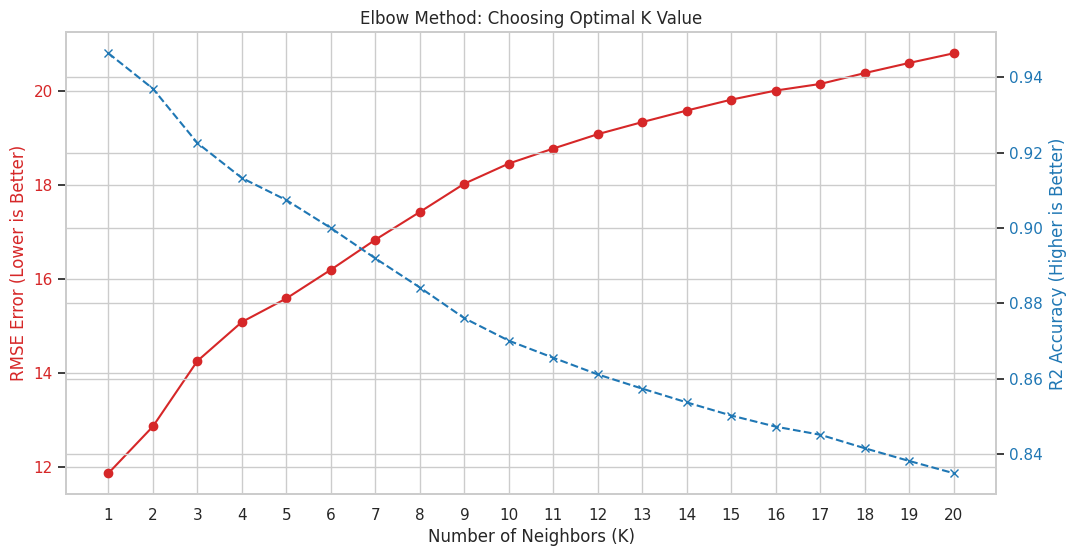

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

#(RMSE)
color = 'tab:red'
ax1.set_xlabel('Number of Neighbors (K)')
ax1.set_ylabel('RMSE Error (Lower is Better)', color=color)
ax1.plot(k_range, rmse_val, marker='o', color=color, label='RMSE')
ax1.tick_params(axis='y', labelcolor=color)

# (Accuracy)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R2 Accuracy (Higher is Better)', color=color)
ax2.plot(k_range, accuracy_val, marker='x', linestyle='--', color=color, label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)


plt.title('Elbow Method: Choosing Optimal K Value')
plt.grid(True)
plt.xticks(k_range)
plt.show()

In [ ]:
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)
evaluate_model(f"KNN Regression (K={best_k})", y_test, y_pred_knn)

🔹 KNN Regression (K=1)
  R2 Score : 0.9464
  RMSE : 11.86
  MAE : 7.47


0.946361255440357

## Model Evaluation


In [ ]:
results_df = pd.DataFrame(results)

In [ ]:
print("\n Detailed Accuracy Metrics Table:")
display(results_df.round(4))


 Detailed Accuracy Metrics Table:


,Model,R2 Score,RMSE,MAE,MSE
0,Linear Regression,0.7538,25.4135,19.4134,645.8452
1,Polynomial Regression (Deg 4),0.8553,19.4826,14.6024,379.5713
2,KNN Regression (K=1),0.9464,11.8612,7.4725,140.6890


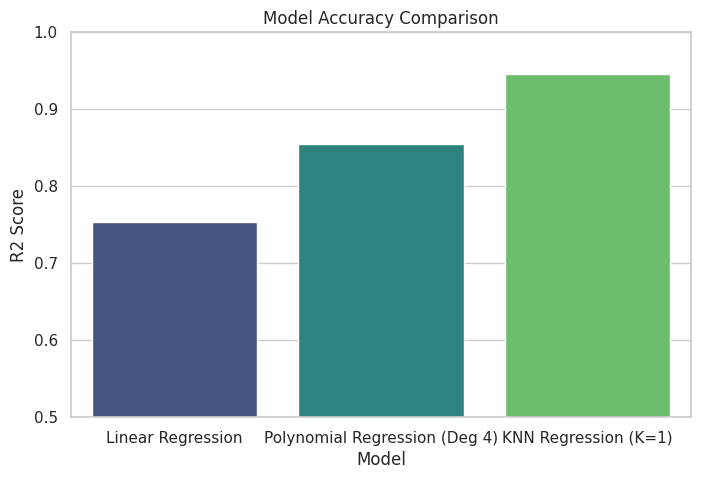

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=results_df, hue='Model', palette='viridis', legend=False)
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison')
plt.show()

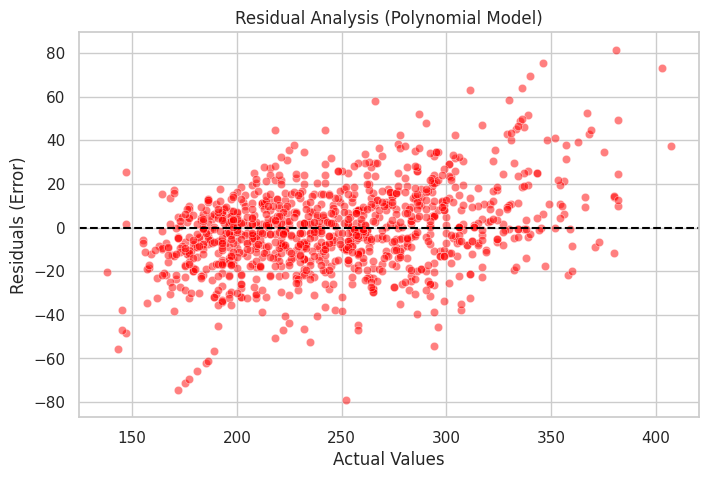

In [ ]:
residuals = y_test - y_pred_poly
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=residuals, color='red', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Residuals (Error)')
plt.title('Residual Analysis (Polynomial Model)')
plt.show()

## Best Model Selection


In [ ]:
best_model_row = results_df.loc[results_df['R2 Score'].idxmax()]
print(f"best_model: {best_model_row['Model']} with R2 Score: {best_model_row['R2 Score']:.4f}")

best_model: KNN Regression (K=1) with R2 Score: 0.9464
